#### Gemini：LobbyView Replication

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# ==========================================
# 1. 全局配置 (Check List 2 - 要素 1)
# ==========================================
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

# ==========================================
# 2. 模拟数据生成 (Requirement 3) - 已修复 KeyError 隐患
# ==========================================
np.random.seed(42)  # 固定种子

corporations = [f"Corp {chr(65+i)}" for i in range(6)]
dem_legislators = [f"Rep. D-{i}" for i in range(1, 16)]
rep_legislators = [f"Rep. R-{i}" for i in range(1, 16)]
legislators = dem_legislators + rep_legislators

parties = {leg: "Democrat" for leg in dem_legislators}
parties.update({leg: "Republican" for leg in rep_legislators})

data = []
# 【修复核心】：首先确保每一个议员都至少能随机分到一家企业的捐款
for leg in legislators:
    assigned_corp = np.random.choice(corporations)
    amount = np.random.uniform(10000, 50000)
    data.append([assigned_corp, leg, parties[leg], amount])

# 随后再随机生成其他的常规游说捐款关系
for corp in corporations:
    selected_legs = np.random.choice(legislators, size=np.random.randint(5, 10), replace=False)
    for leg in selected_legs:
        amount = np.random.uniform(5000, 30000)
        data.append([corp, leg, parties[leg], amount])

df = pd.DataFrame(data, columns=["Corporation", "Legislator", "Party", "Amount"])
# 去重：如果同一企业对同一议员有多次捐款，进行合并
df = df.groupby(["Corporation", "Legislator", "Party"], as_index=False)["Amount"].sum()

# ==========================================
# 3. 核心布局计算 (Check List 2 - 要素 3)
# ==========================================

# 3.1 计算企业在外圈的弧段分配
R = 1.0
corp_totals = df.groupby("Corporation")["Amount"].sum()
total_donations = corp_totals.sum()

gap_angle = 0.05 * (2 * np.pi) / len(corporations)
available_angle = 2 * np.pi - (gap_angle * len(corporations))

corp_angles = {}
current_angle = 0.0
for corp, amount in corp_totals.items():
    span = (amount / total_donations) * available_angle
    corp_angles[corp] = (current_angle, current_angle + span)
    current_angle += span + gap_angle

# 3.2 内部议员节点布局 (严格防重叠)
leg_totals = df.groupby("Legislator")["Amount"].sum()
leg_parties = df.set_index("Legislator")["Party"].to_dict()

leg_coords = {}
for leg in legislators:
    party = parties[leg] # 从全局字典取，确保安全
    r = np.random.uniform(0.1, 0.4)
    if party == "Democrat":
        theta = np.random.uniform(np.pi * 0.6, np.pi * 1.4)
    else:
        theta = np.random.uniform(-np.pi * 0.4, np.pi * 0.4)
    leg_coords[leg] = np.array([r * np.cos(theta), r * np.sin(theta)])

# 力导向排斥迭代
min_dist = 0.07  
for _ in range(200):  
    for l1 in legislators:
        for l2 in legislators:
            if l1 == l2: continue
            pos1, pos2 = leg_coords[l1], leg_coords[l2]
            disp = pos1 - pos2
            dist = np.linalg.norm(disp)
            if dist < min_dist:
                push = (min_dist - dist) * (disp / (dist + 1e-5)) * 0.2
                leg_coords[l1] += push
                leg_coords[l2] -= push
                
                for l in (l1, l2):
                    r = np.linalg.norm(leg_coords[l])
                    if r > 0.5: leg_coords[l] = (leg_coords[l] / r) * 0.5
                    if parties[l] == "Democrat" and leg_coords[l][0] > -0.05:
                        leg_coords[l][0] = -0.05
                    elif parties[l] == "Republican" and leg_coords[l][0] < 0.05:
                        leg_coords[l][0] = 0.05

# ==========================================
# 4. 开始绘制图形 (Check List 2 - 要素 3)
# ==========================================
color_dem = "#1f77b4"  
color_rep = "#d62728"  
party_colors = {"Democrat": color_dem, "Republican": color_rep}

# 4.1 绘制外部企业圆环与扇形连接
for corp, (start_ang, end_ang) in corp_angles.items():
    arc_support = patches.Arc((0, 0), 2*R, 2*R, angle=0, 
                              theta1=np.degrees(start_ang), theta2=np.degrees(end_ang), 
                              color="#dddddd", lw=3.5, zorder=1)
    ax.add_patch(arc_support)
    
    mid_ang = (start_ang + end_ang) / 2
    tx, ty = 1.08 * np.cos(mid_ang), 1.08 * np.sin(mid_ang)
    rot = np.degrees(mid_ang)
    if 90 < rot < 270: rot += 180
    ax.text(tx, ty, corp, ha='center', va='center', rotation=rot, fontsize=10, fontweight='bold', color='#333333')

    corp_df = df[df["Corporation"] == corp]
    corp_total_amount = corp_df["Amount"].sum()
    
    curr_sub_angle = start_ang
    for _, row in corp_df.iterrows():
        leg = row["Legislator"]
        amt = row["Amount"]
        party = row["Party"]
        color = party_colors[party]
        
        sub_span = (amt / corp_total_amount) * (end_ang - start_ang)
        sub_end_angle = curr_sub_angle + sub_span
        
        arc_part = patches.Arc((0, 0), 2*R, 2*R, angle=0, 
                              theta1=np.degrees(curr_sub_angle), theta2=np.degrees(sub_end_angle), 
                              color=color, lw=4, zorder=2)
        ax.add_patch(arc_part)
        
        leg_x, leg_y = leg_coords[leg]
        theta_steps = np.linspace(curr_sub_angle, sub_end_angle, 10)
        poly_pts = [[leg_x, leg_y]]
        for t in theta_steps:
            poly_pts.append([R * np.cos(t), R * np.sin(t)])
        poly_pts.append([leg_x, leg_y])
        
        sector = patches.Polygon(poly_pts, closed=True, facecolor=color, alpha=0.1, edgecolor='none', zorder=1)
        ax.add_patch(sector)
        
        curr_sub_angle = sub_end_angle

# 4.2 绘制内部议员节点
max_donation = leg_totals.max()
for leg in legislators:
    total_amt = leg_totals.get(leg, 0)
    coords = leg_coords[leg]
    party = parties[leg]
    color = party_colors[party]
    
    size_scale = np.sqrt(total_amt / max_donation) * 120  
    ax.scatter(coords[0], coords[1], s=size_scale, color=color, alpha=0.95, edgecolors='none', zorder=3)

# ==========================================
# 5. 外周要素与格式微调 (Check List 2 - 要素 2)
# ==========================================
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axis('off')  

legend_elements = [
    patches.Patch(facecolor=color_dem, label='Democrats (Left Side)'),
    patches.Patch(facecolor=color_rep, label='Republicans (Right Side)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#555555', markersize=8, label='Size $\propto$ Total Donation')
]
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=9.5)

ax.set_title("Circular Anchored Map of Corporate Lobbying and Campaign Contributions", 
             fontsize=13, fontweight='bold', color='#111111', pad=20, loc='center')

plt.tight_layout()
plt.show()

<>:174: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:174: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\lenovo\AppData\Local\Temp\ipykernel_36872\313668267.py:174: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#555555', markersize=8, label='Size $\propto$ Total Donation')


#### Claude Code: LobbyView Replication

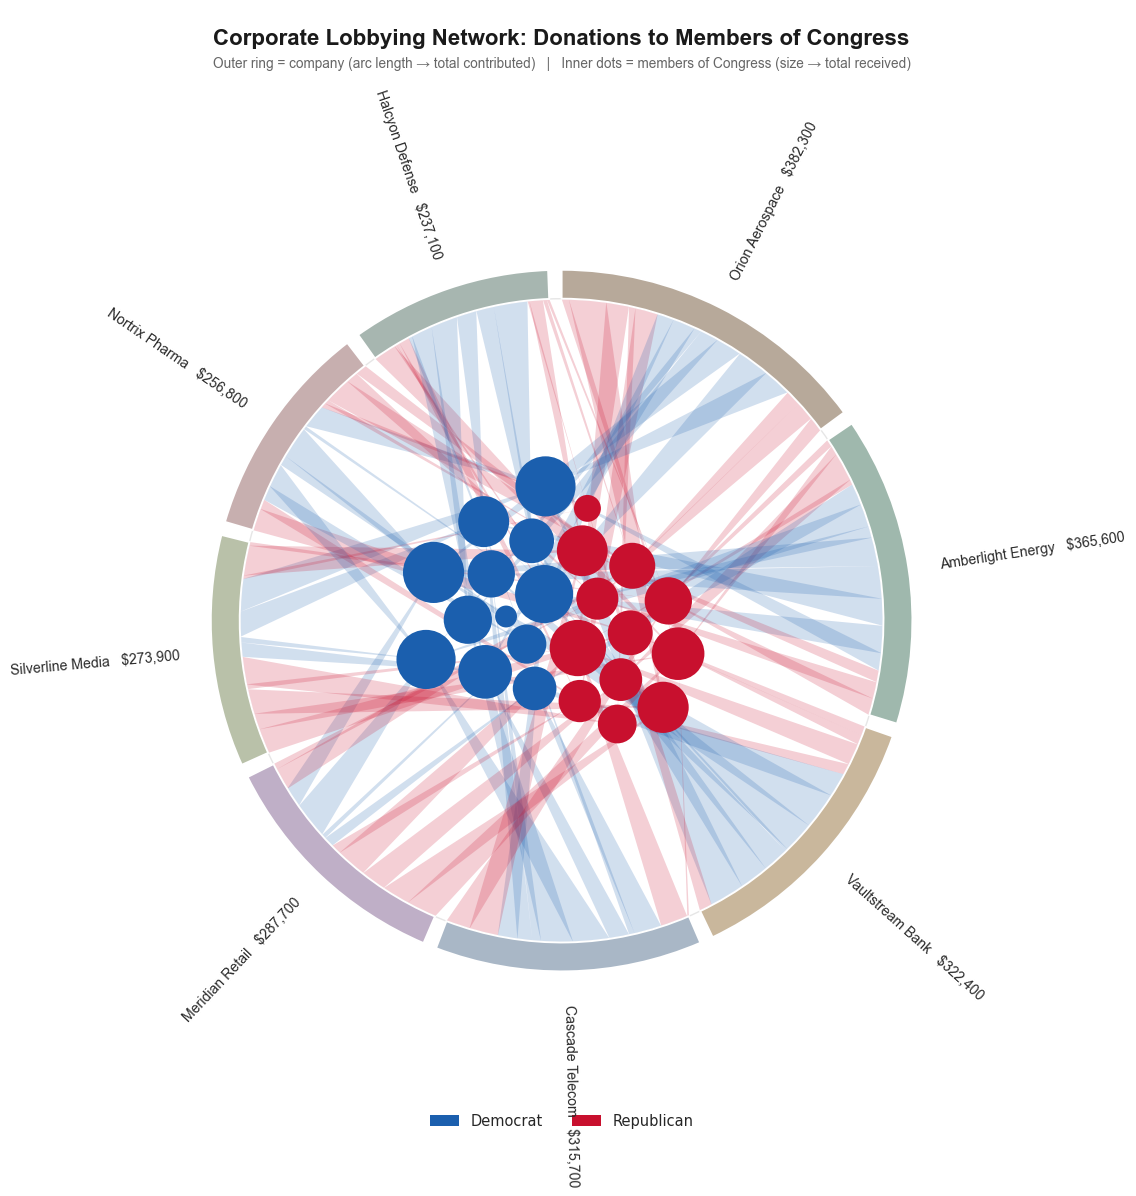

Done. Files written: lobbying_circular_map.png / .pdf, lobbying_circular_map_interactive.html


In [ ]:
"""
Circular Anchored Map: Corporate Lobbying Donations to Members of Congress
============================================================================

Outputs
-------
1. A static chart (matplotlib) -> view inline in Jupyter, also saved as PNG/PDF.
2. An interactive chart (plotly) -> saved as a standalone HTML file, and can
   be shown inline in Jupyter with `fig_interactive.show()`.

Chart design
------------
- Outer ring: one arc per company. Arc length is proportional to the
  company's total contributions.
- Inside the circle: one filled, borderless dot per member of Congress.
  Dot AREA is proportional to the total amount that member received.
- Each company's arc is sliced into segments (one per recipient member).
  Each slice is drawn as a "fan" polygon that connects the arc segment
  (on the outer ring) to the member's dot (the fan's apex) -- this shows
  how much of that company's money went to that specific member.
- Colors: Republican red / Democrat blue, used for member dots AND for the
  fan connecting a company's arc segment to that member (fan = dot color
  at alpha 0.2).
- Layout: Democrats are placed on the left half of the circle, Republicans
  on the right half. All member dots stay reasonably close to the center
  and a force-relaxation step guarantees NO two dots overlap.

Run this file directly:  `python circular_lobbying_map.py`
Or import the functions in a notebook and call them yourself.
"""

import json
import math
import random

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Polygon
import matplotlib.patches as mpatches

import plotly.graph_objects as go

# =============================================================================
# 0. CONFIG
# =============================================================================
SEED = 42

DEM_BLUE = "#1B5FAE"
REP_RED = "#C8102E"
PARTY_COLOR = {"D": DEM_BLUE, "R": REP_RED}

# Muted palette for the outer company-ring bands (kept away from red/blue so
# it never competes visually with the party colors)
COMPANY_COLORS = [
    "#B7A99A", "#9FB8AD", "#C9B79C", "#A9B7C6",
    "#BFAFC7", "#B9C1A9", "#C7AFAF", "#A7B6B0",
]

R_IN = 1.00     # inner edge of the company ring == outer edge of the fan sectors
R_OUT = 1.09    # outer edge of the company ring band
GAP_DEG = 2.2   # gap (degrees) between adjacent company arcs

R_MIN, R_MAX = 0.034, 0.095      # member dot radius bounds (data units)
RMAX_FROM_CENTER = 0.66          # keep dots from wandering too far from center
RMIN_FROM_CENTER = 0.10
DOT_PADDING = 0.012              # minimum gap enforced between any two dots


# =============================================================================
# 1. SIMULATED DATA
# =============================================================================
def generate_data(seed=SEED):
    random.seed(seed)

    companies = [
        "Amberlight Energy", "Nortrix Pharma", "Vaultstream Bank", "Orion Aerospace",
        "Cascade Telecom", "Meridian Retail", "Halcyon Defense", "Silverline Media",
    ]

    # Fictional members of Congress (name, party) -- simulated data only.
    members = [
        ("Sen. Laura Bennett", "D"), ("Rep. Marcus Ellison", "D"),
        ("Sen. Diane Whitfield", "D"), ("Rep. Carlos Ibarra", "D"),
        ("Sen. Priya Anand", "D"), ("Rep. Nathaniel Cho", "D"),
        ("Sen. Rebecca Solis", "D"), ("Rep. Owen Fitzgerald", "D"),
        ("Sen. Grace Talamantes", "D"), ("Rep. Daniel Okafor", "D"),
        ("Sen. Miriam Aldridge", "D"), ("Rep. Victor Lansing", "D"),
        ("Sen. Harold Sinclair", "R"), ("Rep. Beverly Kraus", "R"),
        ("Sen. Gordon Whitaker", "R"), ("Rep. Susan Marchetti", "R"),
        ("Sen. Roy Delacroix", "R"), ("Rep. Patricia Nunn", "R"),
        ("Sen. Walter Hutchins", "R"), ("Rep. Linda Bosworth", "R"),
        ("Sen. Craig Pemberton", "R"), ("Rep. Nora Standish", "R"),
        ("Sen. Edward Kowalski", "R"), ("Rep. Denise Farrow", "R"),
    ]

    records = []
    for c in companies:
        n_recipients = random.randint(10, 16)
        recipients = random.sample(members, n_recipients)
        for name, party in recipients:
            amount = round(random.uniform(2000, 48000), -2)
            records.append({"company": c, "member": name, "party": party, "amount": amount})

    return records


# =============================================================================
# 2. LAYOUT ENGINE
#    (company arcs, member force-relaxation placement, donation fan polygons)
# =============================================================================
def u_to_theta_deg(u):
    """u = degrees measured CLOCKWISE from 12 o'clock -> standard math angle."""
    return 90.0 - u


def polar_xy(theta_deg, r):
    th = math.radians(theta_deg)
    return r * math.cos(th), r * math.sin(th)


def compute_layout(records, seed=SEED):
    rs = np.random.RandomState(seed)

    companies = sorted(set(r["company"] for r in records))
    members_party = {}
    for r in records:
        members_party[r["member"]] = r["party"]
    members = list(members_party.keys())

    # ---- aggregate totals -----------------------------------------------
    company_total = {c: 0.0 for c in companies}
    member_total = {m: 0.0 for m in members}
    for r in records:
        company_total[r["company"]] += r["amount"]
        member_total[r["member"]] += r["amount"]
    grand_total = sum(company_total.values())

    # ---- 1) company arcs on the outer ring -------------------------------
    companies_sorted = sorted(companies, key=lambda c: -company_total[c])
    n_c = len(companies_sorted)
    available_deg = 360 - GAP_DEG * n_c

    u_cursor = 0.0
    company_arc = {}
    for c in companies_sorted:
        span = available_deg * (company_total[c] / grand_total)
        company_arc[c] = (u_cursor, u_cursor + span)
        u_cursor += span + GAP_DEG

    # ---- 2) member dot radii (area ~ total $) -----------------------------
    min_amt, max_amt = min(member_total.values()), max(member_total.values())

    def size_radius(amount):
        if max_amt == min_amt:
            return (R_MIN + R_MAX) / 2
        frac = (amount - min_amt) / (max_amt - min_amt)
        return R_MIN + (R_MAX - R_MIN) * math.sqrt(frac)   # area-proportional

    member_radius = {m: size_radius(member_total[m]) for m in members}

    # ---- 3) force-relaxation layout: Dem -> left half, Rep -> right half --
    pos = {}
    for m in members:
        party = members_party[m]
        theta = rs.uniform(100, 260) if party == "D" else rs.uniform(-80, 80)
        r = rs.uniform(0.25, 0.55)
        pos[m] = np.array(polar_xy(theta, r), dtype=float)

    order = members[:]
    n = len(order)
    for _ in range(4000):
        disp = {m: np.zeros(2) for m in order}
        for i in range(n):
            mi = order[i]
            for j in range(i + 1, n):
                mj = order[j]
                d = pos[mi] - pos[mj]
                dist = np.linalg.norm(d)
                min_dist = member_radius[mi] + member_radius[mj] + DOT_PADDING
                if dist < 1e-6:
                    d = rs.uniform(-1, 1, size=2)
                    dist = np.linalg.norm(d)
                if dist < min_dist:
                    push = (min_dist - dist) * 0.55
                    dirv = d / dist
                    disp[mi] += dirv * push
                    disp[mj] -= dirv * push
        for m in order:
            pos[m] = pos[m] + disp[m]
            party = members_party[m]
            x, y = pos[m]
            buffer = 0.05  # keeps a strict left/right party split
            if party == "D" and x > -buffer:
                x = -buffer - abs(x - (-buffer)) * 0.4
            if party == "R" and x < buffer:
                x = buffer + abs(x - buffer) * 0.4
            pos[m][0] = x
            r = math.hypot(x, y)
            if r > RMAX_FROM_CENTER:
                pos[m] *= RMAX_FROM_CENTER / r
            elif r < RMIN_FROM_CENTER:
                if r < 1e-6:
                    ang = rs.uniform(0, 2 * math.pi)
                    pos[m] = np.array([math.cos(ang), math.sin(ang)]) * RMIN_FROM_CENTER
                else:
                    pos[m] *= (RMIN_FROM_CENTER / r * 0.5 + 0.5)
            pos[m] *= 0.999   # gentle pull toward center -> stays compact

    member_pos = {m: (float(pos[m][0]), float(pos[m][1])) for m in members}

    # ---- 4) donation fan polygons (company arc segment -> member dot) ----
    wedges = []
    for c in companies_sorted:
        recips = [r for r in records if r["company"] == c]

        def theta_of(rec):
            x, y = member_pos[rec["member"]]
            return math.degrees(math.atan2(y, x)) % 360

        recips_sorted = sorted(recips, key=lambda rec: -theta_of(rec))
        u0, u1 = company_arc[c]
        span = u1 - u0
        total_c = company_total[c]
        cursor = u0
        for rec in recips_sorted:
            seg = span * (rec["amount"] / total_c)
            seg_u0, seg_u1 = cursor, cursor + seg
            cursor = seg_u1
            n_steps = max(2, int(seg / 1.5))
            arc_pts = [polar_xy(u_to_theta_deg(seg_u0 + (seg_u1 - seg_u0) * k / n_steps), R_IN)
                       for k in range(n_steps + 1)]
            mx, my = member_pos[rec["member"]]
            wedges.append({
                "company": c, "member": rec["member"], "party": rec["party"],
                "amount": rec["amount"], "polygon": [(mx, my)] + arc_pts + [(mx, my)],
            })

    # ---- 5) company ring band descriptors (for drawing + labels) ---------
    company_bands = []
    for c in companies_sorted:
        u0, u1 = company_arc[c]
        mid_u = (u0 + u1) / 2
        company_bands.append({
            "company": c, "u0": u0, "u1": u1,
            "theta0": u_to_theta_deg(u0), "theta1": u_to_theta_deg(u1),
            "mid_theta": u_to_theta_deg(mid_u), "total": company_total[c],
        })

    return {
        "R_IN": R_IN, "R_OUT": R_OUT,
        "companies": companies_sorted, "company_total": company_total,
        "company_bands": company_bands,
        "members": members, "member_party": members_party,
        "member_total": member_total, "member_radius": member_radius,
        "member_pos": member_pos, "wedges": wedges, "grand_total": grand_total,
    }


# =============================================================================
# 3. STATIC CHART (matplotlib) -- viewable directly in Jupyter
# =============================================================================
def plot_static(D, save_prefix="lobbying_circular_map"):
    fig, ax = plt.subplots(figsize=(11.5, 12.3), facecolor="white")
    ax.set_facecolor("white")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.55, 1.9)
    ax.set_aspect("equal")
    ax.axis("off")

    R_IN, R_OUT = D["R_IN"], D["R_OUT"]

    # company ring bands + labels
    for i, band in enumerate(D["company_bands"]):
        w = Wedge((0, 0), R_OUT, band["theta1"], band["theta0"], width=R_OUT - R_IN,
                   facecolor=COMPANY_COLORS[i % len(COMPANY_COLORS)],
                   edgecolor="white", linewidth=1.4, zorder=3)
        ax.add_patch(w)

        mid = math.radians(band["mid_theta"])
        lx, ly = (R_OUT + 0.10) * math.cos(mid), (R_OUT + 0.10) * math.sin(mid)
        rot = math.degrees(mid)
        ha = "left"
        if 90 < (rot % 360) < 270:
            rot += 180
            ha = "right"
        ax.text(lx, ly, f"{band['company']}   ${band['total']:,.0f}",
                rotation=rot, rotation_mode="anchor", ha=ha, va="center",
                fontsize=10.2, fontweight="medium", color="#2b2b2b",
                family="sans-serif", zorder=6)

    # donation fans
    for w in D["wedges"]:
        color = PARTY_COLOR[w["party"]]
        ax.add_patch(Polygon(w["polygon"], closed=True, facecolor=color,
                              edgecolor="none", alpha=0.20, zorder=2))

    # member dots (solid, borderless)
    for m in D["members"]:
        x, y = D["member_pos"][m]
        r = D["member_radius"][m]
        ax.add_patch(Circle((x, y), r, facecolor=PARTY_COLOR[D["member_party"][m]],
                             edgecolor="none", zorder=5))

    ax.add_patch(Circle((0, 0), R_IN, facecolor="none", edgecolor="#e6e6e6",
                         linewidth=1.0, zorder=1))

    ax.text(0, 1.84, "Corporate Lobbying Network: Donations to Members of Congress",
            ha="center", va="top", fontsize=16, fontweight="bold", color="#1a1a1a",
            family="sans-serif")
    ax.text(0, 1.755,
            "Outer ring = company (arc length \u2192 total contributed)   |   "
            "Inner dots = members of Congress (size \u2192 total received)",
            ha="center", va="top", fontsize=9.8, color="#666666", family="sans-serif")

    legend_elems = [
        mpatches.Patch(facecolor=DEM_BLUE, edgecolor="none", label="Democrat"),
        mpatches.Patch(facecolor=REP_RED, edgecolor="none", label="Republican"),
    ]
    ax.legend(handles=legend_elems, loc="lower center", bbox_to_anchor=(0.5, -0.02),
              ncol=2, frameon=False, fontsize=10.5)

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}.png", dpi=220, facecolor="white", bbox_inches="tight")
        plt.savefig(f"{save_prefix}.pdf", facecolor="white", bbox_inches="tight")
    return fig


# =============================================================================
# 4. INTERACTIVE CHART (plotly) -- standalone HTML + inline Jupyter support
# =============================================================================
def _hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def plot_interactive(D, save_path="lobbying_circular_map_interactive.html"):
    fig = go.Figure()
    R_IN, R_OUT = D["R_IN"], D["R_OUT"]

    # ---- company ring bands (annular sector polygons) ---------------------
    for i, band in enumerate(D["company_bands"]):
        th0, th1 = band["theta0"], band["theta1"]
        thetas_out = np.linspace(th0, th1, 60)
        thetas_in = thetas_out[::-1]
        xs = [R_OUT * math.cos(math.radians(t)) for t in thetas_out] + \
             [R_IN * math.cos(math.radians(t)) for t in thetas_in]
        ys = [R_OUT * math.sin(math.radians(t)) for t in thetas_out] + \
             [R_IN * math.sin(math.radians(t)) for t in thetas_in]
        fig.add_trace(go.Scatter(
            x=xs, y=ys, mode="lines", fill="toself",
            fillcolor=COMPANY_COLORS[i % len(COMPANY_COLORS)],
            line=dict(color="white", width=1.2),
            hoveron="fills", hoverinfo="text",
            text=f"{band['company']}<br>Total contributed: ${band['total']:,.0f}",
            showlegend=False,
        ))

        mid = math.radians(band["mid_theta"])
        lx, ly = (R_OUT + 0.10) * math.cos(mid), (R_OUT + 0.10) * math.sin(mid)
        rot = math.degrees(mid)
        ha = "left"
        if 90 < (rot % 360) < 270:
            rot += 180
            ha = "right"
        fig.add_annotation(
            x=lx, y=ly, text=f"{band['company']}  ${band['total']:,.0f}",
            showarrow=False, textangle=-rot, font=dict(size=12, color="#2b2b2b"),
            xanchor=ha, yanchor="middle",
        )

    # ---- donation fans (company arc segment -> member dot) ---------------
    for w in D["wedges"]:
        xs = [p[0] for p in w["polygon"]]
        ys = [p[1] for p in w["polygon"]]
        fig.add_trace(go.Scatter(
            x=xs, y=ys, mode="lines", fill="toself",
            fillcolor=_hex_to_rgba(PARTY_COLOR[w["party"]], 0.20),
            line=dict(width=0),
            hoveron="fills", hoverinfo="text",
            text=f"{w['company']} \u2192 {w['member']}<br>${w['amount']:,.0f}",
            showlegend=False,
        ))

    # ---- member dots (area ~ total $ received) ----------------------------
    max_r = max(D["member_radius"].values())
    # convert data-unit radius to plotly marker size (points, diameter-based)
    PIXELS_FOR_MAX_RADIUS = 46
    for party, label, color in [("D", "Democrat", DEM_BLUE), ("R", "Republican", REP_RED)]:
        xs, ys, sizes, texts = [], [], [], []
        for m in D["members"]:
            if D["member_party"][m] != party:
                continue
            x, y = D["member_pos"][m]
            r = D["member_radius"][m]
            xs.append(x)
            ys.append(y)
            sizes.append(2 * PIXELS_FOR_MAX_RADIUS * (r / max_r))
            texts.append(f"{m} ({party})<br>Total received: ${D['member_total'][m]:,.0f}")
        fig.add_trace(go.Scatter(
            x=xs, y=ys, mode="markers", name=label,
            marker=dict(size=sizes, color=color, line=dict(width=0), sizemode="diameter"),
            hoverinfo="text", text=texts,
        ))

    fig.update_layout(
        title=dict(
            text="Corporate Lobbying Network: Donations to Members of Congress"
                 "<br><sup>Outer ring = company (arc length \u2192 total contributed) "
                 "&nbsp;|&nbsp; Inner dots = members of Congress (size \u2192 total received)</sup>",
            x=0.5, xanchor="center", font=dict(size=18),
        ),
        plot_bgcolor="white", paper_bgcolor="white",
        width=950, height=1000,
        xaxis=dict(visible=False, range=[-1.5, 1.5], scaleanchor="y", scaleratio=1),
        yaxis=dict(visible=False, range=[-1.55, 1.55]),
        legend=dict(orientation="h", yanchor="bottom", y=-0.03, xanchor="center", x=0.5,
                    font=dict(size=12)),
        margin=dict(l=40, r=40, t=110, b=40),
    )

    if save_path:
        fig.write_html(save_path, include_plotlyjs="cdn")
    return fig


# =============================================================================
# 5. MAIN
# =============================================================================
if __name__ == "__main__":
    records = generate_data(seed=SEED)
    D = compute_layout(records, seed=SEED)

    static_fig = plot_static(D, save_prefix="lobbying_circular_map")
    plt.show()   # in Jupyter this renders inline

    interactive_fig = plot_interactive(D, save_path="lobbying_circular_map_interactive.html")
    # interactive_fig.show()   # uncomment in Jupyter to render inline
    print("Done. Files written: lobbying_circular_map.png / .pdf, "
          "lobbying_circular_map_interactive.html")